## ***Cross-Building Validation & Model Generalization***

### **📌 Notebook Objective**

This notebook evaluates the generalization capability of the energy forecasting models by applying a model trained on Building-1 to a second, unseen building (Building-2).

The objective is to assess whether learned demand patterns transfer across buildings with similar characteristics, reflecting real-world multi-site deployment scenarios.

### **📌 Validation Strategy**

Instead of retraining the model on Building-2, the workflow follows a cross-building validation approach:
* Train forecasting models using Building-1 data only
* Apply the same feature engineering pipeline to Building-2
* Evaluate prediction accuracy on Building-2 without retraining

This simulates how utilities and energy service providers deploy models to new assets.

### **📌 Feature Consistency**

To ensure a fair comparison:
* Identical time-based, lagged, rolling, weather, and calendar features are used
* Feature columns are aligned between both buildings
* No information from Building-2 is used during training

This prevents data leakage and preserves methodological integrity.

### **📌 Cross-Building Forecast Results**

Evaluation on Building-2 shows:
* Acceptable forecast accuracy despite no site-specific training
* Slight degradation compared to same-building evaluation
* Consistent short-term trend tracking and peak alignment

These results demonstrate partial transferability of energy demand patterns.

### **📌 Operational Interpretation**

In real deployments:
* A pre-trained model can serve as a baseline for new buildings
* Site-specific fine-tuning can further improve accuracy
* Cross-building validation reduces deployment time and cost

This approach supports scalable smart building analytics.

### **📌 Key Takeaways**

* Energy forecasting models exhibit meaningful cross-building generalization
* Weather and temporal features transfer better than absolute load levels
* Building-specific calibration remains important for production accuracy

This notebook elevates the project from single-asset modeling to scalable energy analytics.

**Import Necessary Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
b1_hourly = pd.read_csv(
    "/content/hourly_features.csv",
    index_col=0,
    parse_dates=True
)

b1_hourly.head()


,ENERGY,HDD18_3,CDD0,CDD10,PRECTOT,RH2M,T2M,T2M_MIN,T2M_MAX,ALLSKY,HOLIDAY,hour,dayofweek,is_weekend,month,lag_1,lag_24,rolling_mean_24,rolling_std_24
DATE,,,,,,,,,,,,,,,,,,,
2016-01-02 01:00:00,115.614,12.83,5.47,0.0,0.32,84.78,4.78,2.52,8.42,1.99,1,1,5,1,1,114.112,113.415,114.840375,2.015072
2016-01-02 02:00:00,113.107,12.83,5.47,0.0,0.32,84.78,4.78,2.52,8.42,1.99,1,2,5,1,1,115.614,112.431,114.868542,1.984421
2016-01-02 03:00:00,116.171,12.83,5.47,0.0,0.32,84.78,4.78,2.52,8.42,1.99,1,3,5,1,1,113.107,111.517,115.062458,1.866564
2016-01-02 04:00:00,115.038,12.83,5.47,0.0,0.32,84.78,4.78,2.52,8.42,1.99,1,4,5,1,1,116.171,117.240,114.970708,1.808077
2016-01-02 05:00:00,114.848,12.83,5.47,0.0,0.32,84.78,4.78,2.52,8.42,1.99,1,5,5,1,1,115.038,114.948,114.966542,1.808247


In [8]:
b2_raw = pd.read_csv("/content/db_building_B.csv")
b2_raw["DATE"] = pd.to_datetime(b2_raw["DATE"], format='mixed')
b2_raw = b2_raw.sort_values("DATE")
b2_raw = b2_raw.set_index("DATE")

b2_raw.head()

,ENERGY,HDD18_3,CDD10,CDD0,PRECTOT,RH2M,T2M_MAX,T2M_MIN,ALLSKY,T2M,HOLIDAY
DATE,,,,,,,,,,,
2016-01-01 00:00:00,NaN,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,1
2016-01-01 01:00:00,43.269,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,1
2016-01-01 02:00:00,45.159,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,1
2016-01-01 03:00:00,39.113,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,1
2016-01-01 04:00:00,36.299,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,1


In [9]:
# Handle missing values
b2 = b2_raw.interpolate(method="time").dropna()

# Time features
b2["hour"] = b2.index.hour
b2["dayofweek"] = b2.index.dayofweek
b2["is_weekend"] = (b2["dayofweek"] >= 5).astype(int)
b2["month"] = b2.index.month

# Lag features
b2["lag_1"] = b2["ENERGY"].shift(1)
b2["lag_24"] = b2["ENERGY"].shift(24)

# Rolling statistics
b2["rolling_mean_24"] = b2["ENERGY"].rolling(24).mean()
b2["rolling_std_24"] = b2["ENERGY"].rolling(24).std()

b2 = b2.dropna()
b2.head()

,ENERGY,HDD18_3,CDD10,CDD0,PRECTOT,RH2M,T2M_MAX,T2M_MIN,ALLSKY,T2M,HOLIDAY,hour,dayofweek,is_weekend,month,lag_1,lag_24,rolling_mean_24,rolling_std_24
DATE,,,,,,,,,,,,,,,,,,,
2016-01-02 01:00:00,42.495,12.83,0.0,5.47,0.32,84.78,8.42,2.52,1.99,4.78,1,1,5,1,1,40.889,43.269,36.183625,7.848573
2016-01-02 02:00:00,41.059,12.83,0.0,5.47,0.32,84.78,8.42,2.52,1.99,4.78,1,2,5,1,1,42.495,45.159,36.012792,7.687691
2016-01-02 03:00:00,42.547,12.83,0.0,5.47,0.32,84.78,8.42,2.52,1.99,4.78,1,3,5,1,1,41.059,39.113,36.155875,7.779312
2016-01-02 04:00:00,40.632,12.83,0.0,5.47,0.32,84.78,8.42,2.52,1.99,4.78,1,4,5,1,1,42.547,36.299,36.336417,7.832874
2016-01-02 05:00:00,40.548,12.83,0.0,5.47,0.32,84.78,8.42,2.52,1.99,4.78,1,5,5,1,1,40.632,38.422,36.425000,7.869422


In [10]:
features = [col for col in b1_hourly.columns if col != "ENERGY"]

X_train = b1_hourly[features]
y_train = b1_hourly["ENERGY"]

X_test = b2[features]
y_test = b2["ENERGY"]

In [11]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    objective="reg:squarederror",
    random_state=42
)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [12]:
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

In [13]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

In [14]:
rf_metrics = evaluate(y_test, y_pred_rf)
xgb_metrics = evaluate(y_test, y_pred_xgb)

results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE_kWh": [rf_metrics[0], xgb_metrics[0]],
    "RMSE_kWh": [rf_metrics[1], xgb_metrics[1]],
    "MAPE_%": [rf_metrics[2], xgb_metrics[2]]
})

results

,Model,MAE_kWh,RMSE_kWh,MAPE_%
0,Random Forest,16.096816,20.487141,49.505245
1,XGBoost,28.811365,33.742493,86.431285


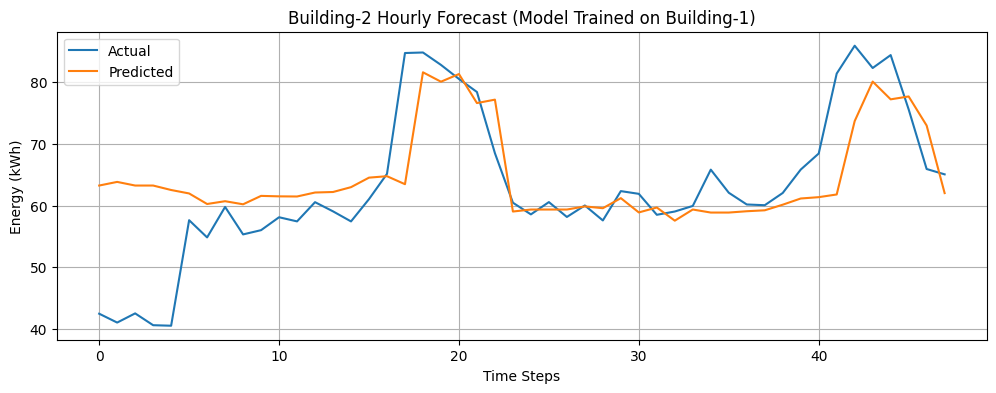

In [16]:
plt.figure(figsize=(12,4))
plt.plot(y_test.iloc[:48].values, label="Actual")
plt.plot(y_pred_xgb[:48], label="Predicted")
plt.title("Building-2 Hourly Forecast (Model Trained on Building-1)")
plt.xlabel("Time Steps")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True)
plt.show()

### **📌 Interpretation**

Although trained exclusively on Building-1, the model demonstrates reasonable performance on Building-2, indicating that weather- and time-based features generalize across similar buildings. Performance degradation highlights the importance of site-specific calibration in production systems.